In [48]:
import numpy as np
import torch
from torch.distributions import constraints
import scipy.stats
from math import sqrt
from sbi.utils import process_prior
from sbi.utils.user_input_checks import process_simulator
from sbi.inference import NPE_C, simulate_for_sbi
import pickle, yaml, os, time, argparse
from pathlib import Path
import matplotlib.pyplot as plt
from examples.stoch_vol import SVMPrior  # wherever you originally defined it

In [49]:
trajectories_path = "/Users/Lieve/Documents/Masters Project/SBC-SBI/results/real_examples/stoch_vol/data/"
results_path = "/Users/Lieve/Documents/Masters Project/SBC-SBI/results/real_examples/stoch_vol/npe_c/"

experiment_ID = 0
posteriors_config_path = results_path + f"sequential_posterior{experiment_ID}.yaml"
posteriors_path = results_path + f"sequential_posterior{experiment_ID}_posteriors_dict.pkl"

with open(posteriors_config_path, "r") as f:
    posteriors_config = yaml.safe_load(f)

with open(posteriors_path, "rb") as f:
    posteriors_dict = pickle.load(f)

In [50]:
# Assign variables
x_observed_ID = posteriors_config["x_observed_ID"]
num_sequential_rounds = posteriors_config["num_sequential_rounds"]
num_simulations_per_round = posteriors_config["num_simulations_per_round"]
simulation_times = posteriors_config["simulation_times"]
training_times = posteriors_config["training_times"]
use_combined_loss = posteriors_config["use_combined_loss"]
density_estimator = posteriors_config["density_estimator"]
sigma2_alpha = posteriors_config["sigma2_alpha"]
sigma2_beta = posteriors_config["sigma2_beta"]
beta2_alpha = posteriors_config["beta2_alpha"]
beta2_beta = posteriors_config["beta2_beta"]
rho_lower = posteriors_config["rho_lower"]
rho_upper = posteriors_config["rho_upper"]
T = posteriors_config["T"]
initial_distribution_variance = posteriors_config["initial_distribution_variance"]

In [51]:
trajectory_path = trajectories_path + f"trajectory{x_observed_ID}.npz"
trajectory_config_path = trajectories_path + f"trajectory{x_observed_ID}.yaml"

trajectory = np.load(trajectory_path)
with open(trajectory_config_path, "r") as f:
    trajectory_config = yaml.safe_load(f)

In [52]:
z = trajectory["z"][: T+1]
x_observed = trajectory["x"][: T+1]

beta2_true = trajectory_config["beta2_true"]
beta_true = trajectory_config["beta_true"]
initial_distribution_variance = trajectory_config["initial_distribution_variance"]
rho_true = trajectory_config["rho_true"]
sigma2_true = trajectory_config["sigma2_true"]
sigma_true = trajectory_config["sigma_true"]

In [53]:
round_ID = 1
posterior = posteriors_dict[f"round_{round_ID}"]
samples = posterior.sample((10000,))

sigma2_samples = samples[:, 0]
beta2_samples = samples[:, 1]
rho_samples = samples[:, 2]
z_0_to_T_samples = samples[:, 3:]

Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]

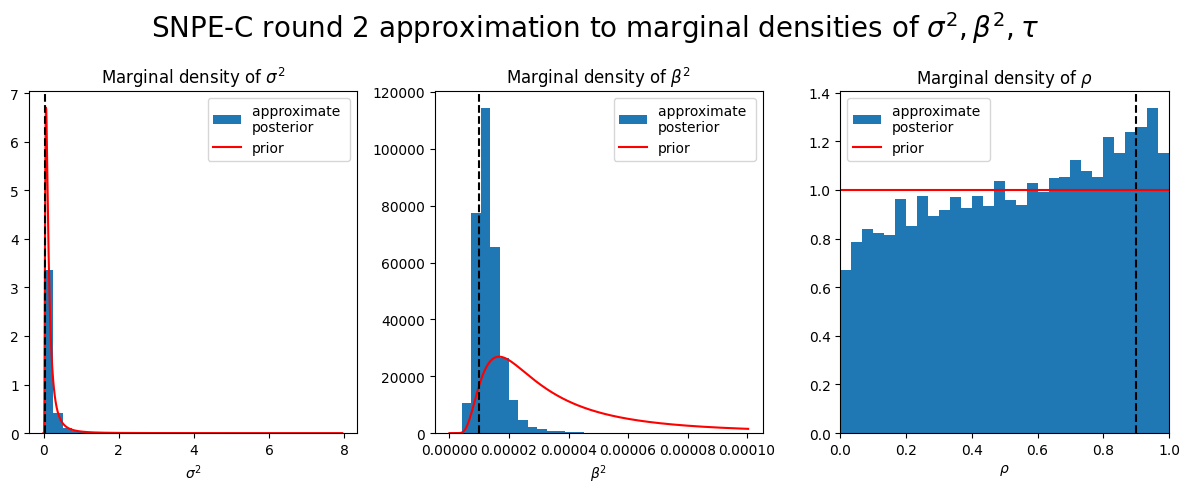

In [54]:
fig, ax = plt.subplots(figsize=(12,5), ncols=3)
bins=30

ax[0].hist(sigma2_samples, bins=bins, density=True, label="approximate \nposterior")
xl, xu = ax[0].get_xlim()
ax[0].plot(np.linspace(0,xu,1000), 
           scipy.stats.invgamma.pdf(np.linspace(0,xu,1000), a=sigma2_alpha, scale=sigma2_beta),
           color="red", label=r"prior")
ax[0].axvline(sigma2_true, color="k", linestyle="--")
ax[0].set_xlabel(r"$\sigma^2$")
ax[0].set_title(r"Marginal density of $\sigma^2$")
ax[0].legend()

ax[1].hist(beta2_samples, bins=bins, density=True, label="approximate \nposterior")
xl, xu = ax[1].get_xlim()
ax[1].plot(np.linspace(0,xu,1000), 
           scipy.stats.invgamma.pdf(np.linspace(0,xu,1000), a=beta2_alpha, scale=beta2_beta),
           color="red", label=r"prior")
ax[1].axvline(beta2_true, color="k", linestyle="--")
ax[1].set_xlabel(r"$\beta^2$")
ax[1].set_title(r"Marginal density of $\beta^2$")
ax[1].legend()

ax[2].set_xlim(rho_lower, rho_upper)
ax[2].hist(rho_samples, bins=bins, density=True, label="approximate \nposterior")
ax[2].axvline(rho_true, color="k", linestyle="--")
ax[2].axhline(1/(rho_upper - rho_lower), xmin=rho_lower, xmax=rho_upper, color="red", label=r"prior")
ax[2].set_xlabel(r"$\rho$")
ax[2].set_title(r"Marginal density of $\rho$")
ax[2].legend()

plt.suptitle(f"SNPE-C round {round_ID+1} approximation to marginal densities of " + r"$\sigma^2, \beta^2, \tau$", fontsize=20)
plt.tight_layout()
plt.show()

Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]

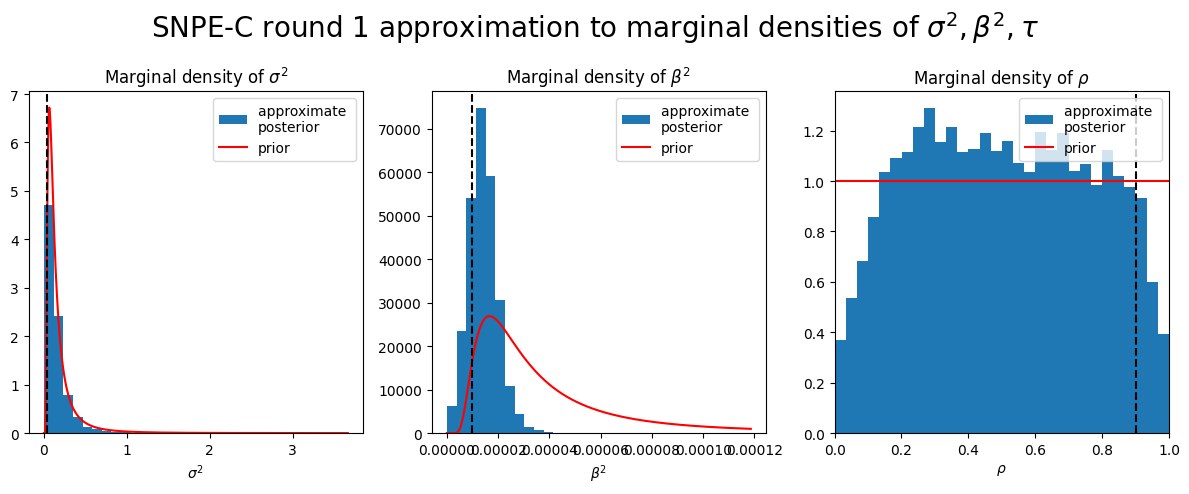

Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]

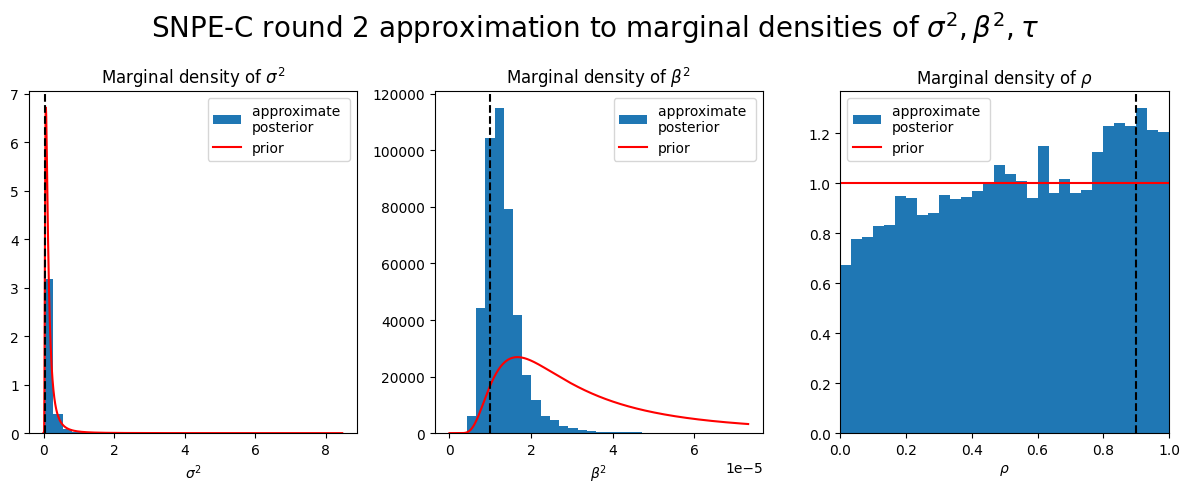

Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]

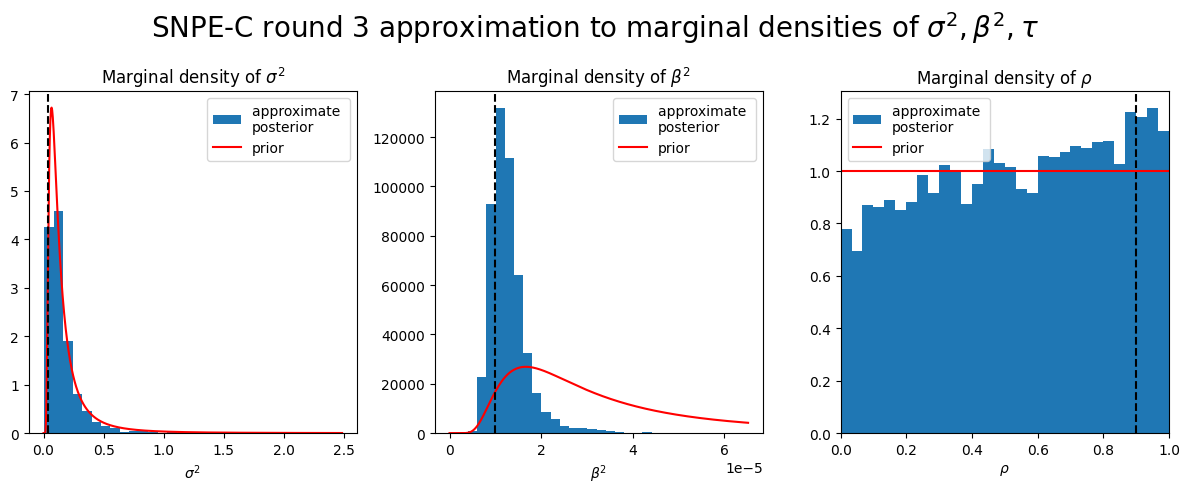

Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]

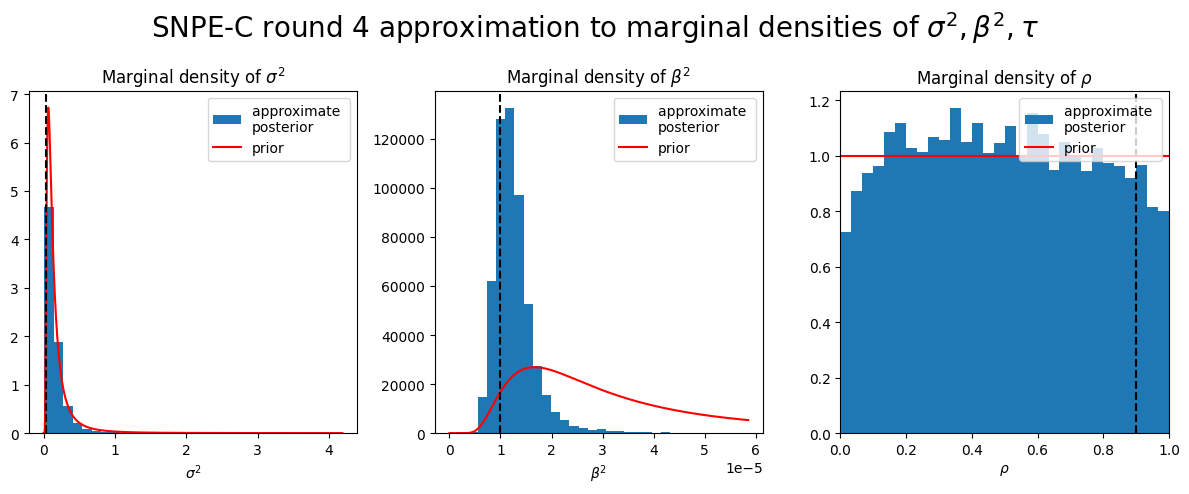

Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]

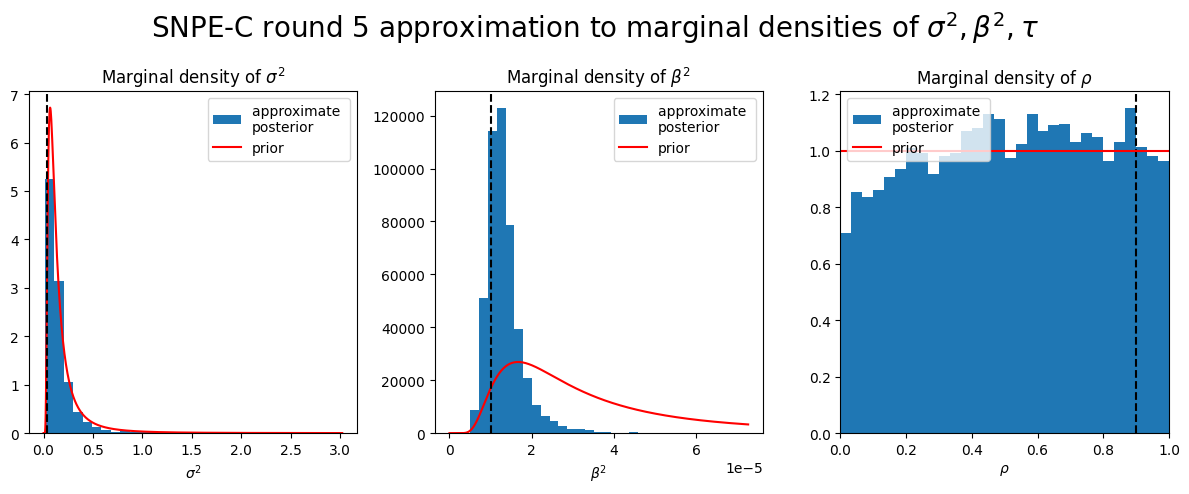

Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]

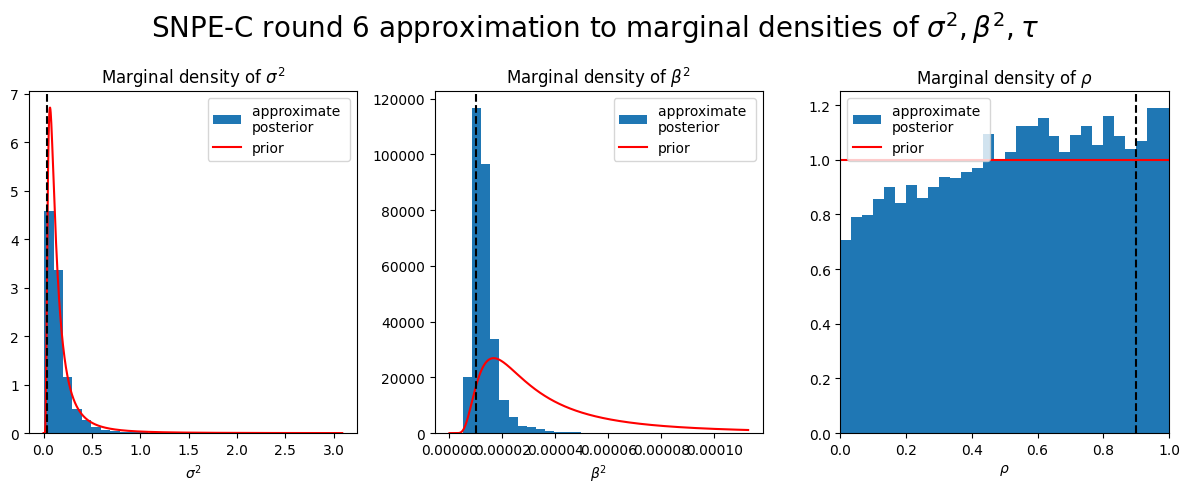

In [55]:
for round_ID in range(6):
    posterior = posteriors_dict[f"round_{round_ID}"]
    samples = posterior.sample((10000,))

    sigma2_samples = samples[:, 0]
    beta2_samples = samples[:, 1]
    rho_samples = samples[:, 2]
    z_0_to_T_samples = samples[:, 3:]

    fig, ax = plt.subplots(figsize=(12,5), ncols=3)
    bins=30

    ax[0].hist(sigma2_samples, bins=bins, density=True, label="approximate \nposterior")
    xl, xu = ax[0].get_xlim()
    ax[0].plot(np.linspace(0,xu,1000), 
            scipy.stats.invgamma.pdf(np.linspace(0,xu,1000), a=sigma2_alpha, scale=sigma2_beta),
            color="red", label=r"prior")
    ax[0].axvline(sigma2_true, color="k", linestyle="--")
    ax[0].set_xlabel(r"$\sigma^2$")
    ax[0].set_title(r"Marginal density of $\sigma^2$")
    ax[0].legend()

    ax[1].hist(beta2_samples, bins=bins, density=True, label="approximate \nposterior")
    xl, xu = ax[1].get_xlim()
    ax[1].plot(np.linspace(0,xu,1000), 
            scipy.stats.invgamma.pdf(np.linspace(0,xu,1000), a=beta2_alpha, scale=beta2_beta),
            color="red", label=r"prior")
    ax[1].axvline(beta2_true, color="k", linestyle="--")
    ax[1].set_xlabel(r"$\beta^2$")
    ax[1].set_title(r"Marginal density of $\beta^2$")
    ax[1].legend()

    ax[2].set_xlim(rho_lower, rho_upper)
    ax[2].hist(rho_samples, bins=bins, density=True, label="approximate \nposterior")
    ax[2].axvline(rho_true, color="k", linestyle="--")
    ax[2].axhline(1/(rho_upper - rho_lower), xmin=rho_lower, xmax=rho_upper, color="red", label=r"prior")
    ax[2].set_xlabel(r"$\rho$")
    ax[2].set_title(r"Marginal density of $\rho$")
    ax[2].legend()

    plt.suptitle(f"SNPE-C round {round_ID + 1} approximation to marginal densities of " + r"$\sigma^2, \beta^2, \tau$", fontsize=20)
    plt.tight_layout()
    plt.show()